In [1]:
import numpy as np
import matplotlib.pyplot as plt
from epymorph.attribute import NamePattern
from epymorph.kit import *

from epymorph.simulation import Context
from epymorph.adrio import acs5, us_tiger
from epymorph.forecasting.dynamic_params import GaussianPrior, OrnsteinUhlenbeck,ExponentialTransform
from epymorph.forecasting.pipeline import (ParticleFilterSimulator,
EnsembleKalmanFilterSimulator,
Observations,
ModelLink,
PipelineConfig,
UnknownParam,
munge_pipeline_output)

from epymorph.forecasting.likelihood import Poisson

In [2]:
from typing_extensions import override
from epymorph.initializer import _POPULATION_ATTR
from epymorph.initializer import *


class RandomLocationsAndRandomSeed(SeededInfection):
    """
    Seed an random number of infected in a number of randomly selected locations.

    Requires "population" as a data attribute.

    Parameters
    ----------
    num_locations :
        The number of locations to choose.
    seed_max :
        The maximum number of individuals to infect.
    initial_compartment :
        Which compartment (by index or name) is "not infected", where most individuals
        start out.
    infection_compartment :
        Which compartment (by index or name) will be seeded as the initial infection.
    """

    requirements = (_POPULATION_ATTR,)

    num_locations: int
    """The number of locations to choose (randomly)."""
    seed_max: int
    """The maximum number of individuals to infect, drawn uniformly on [0,seed_max]."""

    def __init__(
        self,
        num_locations: int,
        seed_max: int,
        initial_compartment: int | str = SeededInfection.DEFAULT_INITIAL,
        infection_compartment: int | str = SeededInfection.DEFAULT_INFECTION,
    ):
        super().__init__(initial_compartment, infection_compartment)
        self.num_locations = num_locations
        self.seed_max = seed_max

    @override
    def evaluate(self) -> SimArray:
        """
        Evaluate the initializer in the current context.

        Returns
        -------
        :
            The initial populations for each node and IPM compartment.
        """
        N = self.scope.nodes
        if not 0 < self.num_locations <= N:
            err = (
                "Initializer argument 'num_locations' must be "
                f"a value from 1 up to the number of locations ({N})."
            )
            raise InitError(err)

        indices = np.arange(N, dtype=np.intp)
        selection = self.rng.choice(indices, self.num_locations)
        seed_size = self.rng.integers(low=0, high=self.seed_max, endpoint=True)

        sub = IndexedLocations(
            selection=selection,
            seed_size=seed_size,
            initial_compartment=self.initial_compartment,
            infection_compartment=self.infection_compartment,
        )
        return self.defer(sub)

In [3]:
my_rng = np.random.default_rng(0)

In [4]:
from epymorph.forecasting.dynamic_params import BrownianMotion

my_unknown_params = {
        "log_beta": UnknownParam(
        prior=GaussianPrior(mean = np.log(0.2),standard_deviation=0.5),
        dynamics=BrownianMotion(
           voliatility = 0.1
        ))
        }

In [5]:
from epymorph.forecasting.likelihood import Gaussian, NegativeBinomial
from epymorph.adrio import acs5, commuting_flows, us_tiger
from epymorph.adrio.cdc import InfluenzaStateHospitalizationDaily


num_realizations = 100

locations = ["WA","OR","CA","ID"]
inf_rume = SingleStrataRUME.build(
    ipm=ipm.SIRH(),
    mm=mm.Centroids(),
    scope=StateScope.in_states(locations,year=2015),
    init=RandomLocationsAndRandomSeed(
        num_locations=len(locations),
        seed_max=10_000
    ),
    time_frame=TimeFrame.of("2022-09-15", 7 * 26 + 1),
    params={
        "beta": ExponentialTransform("log_beta"),
        "gamma": 0.2,
        "xi": 1 / 90,
        "phi": 5,
        "hospitalization_prob": 150/100_000,
        "hospitalization_duration": 5,
        "centroid": us_tiger.InternalPoint(),
        "population": acs5.Population(),
        "label": us_tiger.Name(),
    },
)

my_observations = Observations(
    source=InfluenzaStateHospitalizationDaily(column = 'admissions'),
    model_link=ModelLink(
        geo=inf_rume.scope.select.all(),
        time=inf_rume.time_frame.select.all().group("day").agg(),
        quantity=inf_rume.ipm.select.events("I->H"),
    ),
    likelihood=NegativeBinomial(10)
)

particle_filter_simulator = ParticleFilterSimulator(
    config=PipelineConfig.from_rume(
        inf_rume, num_realizations, unknown_params=my_unknown_params
    ),
    observations=my_observations,
)


In [6]:
particle_filter_output = particle_filter_simulator.run(rng=my_rng)


Observation: 0, Label: 2022-09-15, Time Frame: 2022-09-15 (1D)
Observation: 1, Label: 2022-09-16, Time Frame: 2022-09-16 (1D)
Observation: 2, Label: 2022-09-17, Time Frame: 2022-09-17 (1D)
Observation: 3, Label: 2022-09-18, Time Frame: 2022-09-18 (1D)
Observation: 4, Label: 2022-09-19, Time Frame: 2022-09-19 (1D)
Observation: 5, Label: 2022-09-20, Time Frame: 2022-09-20 (1D)
Observation: 6, Label: 2022-09-21, Time Frame: 2022-09-21 (1D)
Observation: 7, Label: 2022-09-22, Time Frame: 2022-09-22 (1D)
Observation: 8, Label: 2022-09-23, Time Frame: 2022-09-23 (1D)
Observation: 9, Label: 2022-09-24, Time Frame: 2022-09-24 (1D)
Observation: 10, Label: 2022-09-25, Time Frame: 2022-09-25 (1D)
Observation: 11, Label: 2022-09-26, Time Frame: 2022-09-26 (1D)
Observation: 12, Label: 2022-09-27, Time Frame: 2022-09-27 (1D)
Observation: 13, Label: 2022-09-28, Time Frame: 2022-09-28 (1D)
Observation: 14, Label: 2022-09-29, Time Frame: 2022-09-29 (1D)
Observation: 15, Label: 2022-09-30, Time Frame: 20

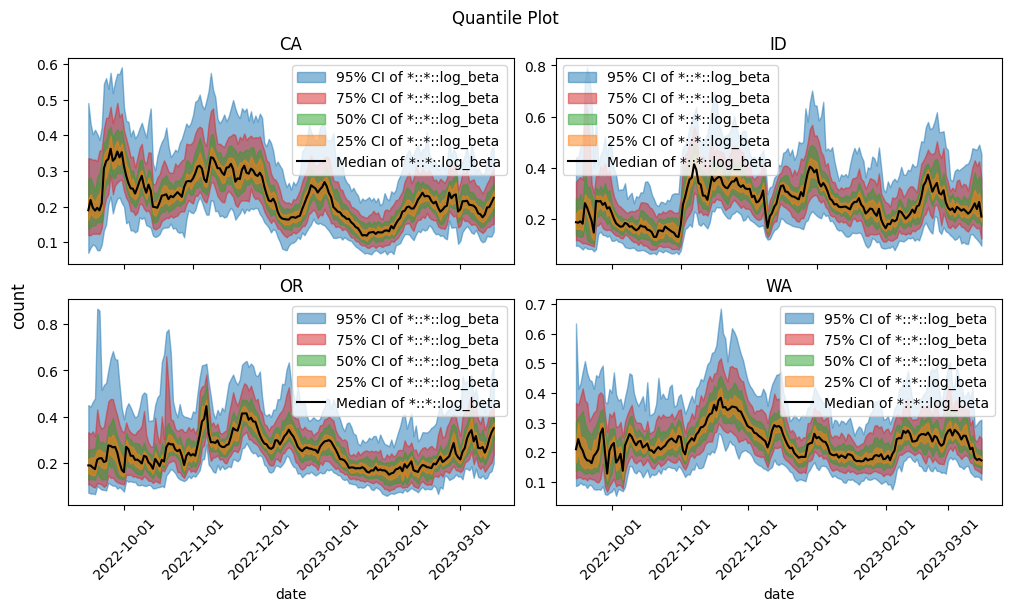

In [7]:
from epymorph.forecasting.filter_plot import PlotRendererFilter

from math import log, nan, exp


def exp_transform(data_df):
    # we have to be careful to avoid log(0)!
    log_value = data_df["value"].apply(lambda x: exp(x))
    return data_df.assign(value=log_value)


realization = particle_filter_output.select.all()
time = inf_rume.time_frame.select.all().group("day").agg()
geo = inf_rume.scope.select.all()
quantity = particle_filter_output.param_select.all()

plotter = PlotRendererFilter(particle_filter_output)

plotter.quantiles(
    geo,
    time,
    quantity,
    ncols=2,
    credible_intervals=[
        95,
        75,
        50,
        25
    ],  # fill_kwargs will be assigned based on the sorted list
    fill_kwargs=[
        {"alpha": 0.5, "color": "tab:blue"},
        {"alpha": 0.5, "color": "tab:red"},
        {"alpha": 0.5, "color": "tab:green"},
        {"alpha": 0.5, "color": "tab:orange"}
    ],  # Fill arguments for each interval
    line_kwargs=[{"color": "black"}],  # For the median line
    title = "Quantile Plot",
    legend = "on",
    transform = exp_transform
)

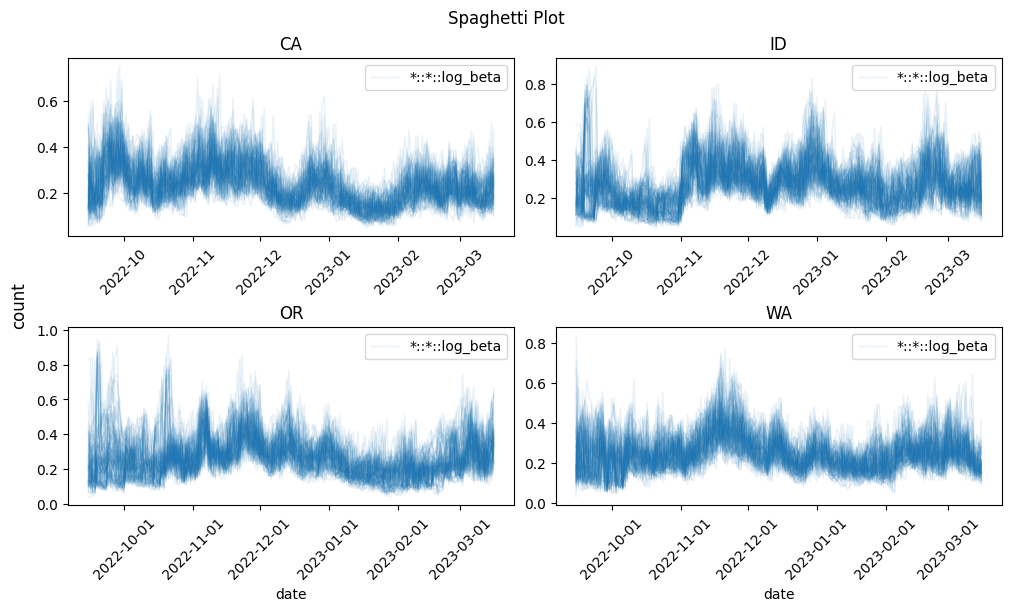

In [8]:
realization = particle_filter_output.select.all()
time = inf_rume.time_frame.select.all().group("day").agg()
geo = inf_rume.scope.select.all()
quantity = particle_filter_output.param_select.all()

plotter.spaghetti(
    realization,
    geo,
    time,
    quantity,
    ncols=2,
    sharex = False,
    line_kwargs=[{"alpha": 0.1, "color": "tab:blue", "lw": 1.0}],
    transform=exp_transform,
    title="Spaghetti Plot",
)

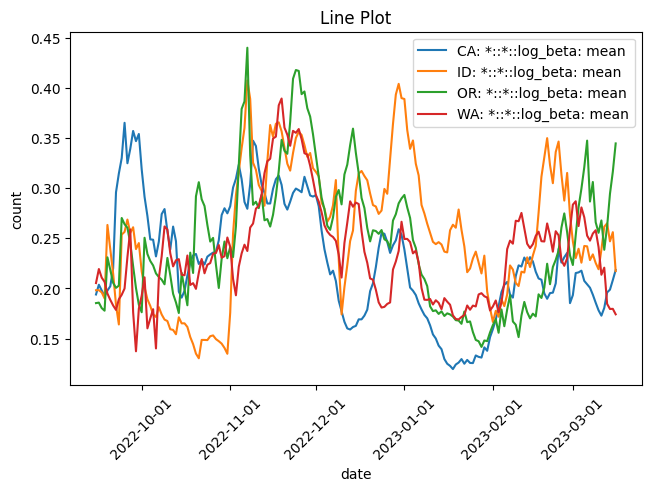

In [9]:
realization = particle_filter_output.select.all().agg(["mean"])
time = inf_rume.time_frame.select.all().group("day").agg()
geo = inf_rume.scope.select.all()
quantity = particle_filter_output.param_select.all()

plotter.line(
    realization,
    geo,
    time,
    quantity,
    title = "Line Plot",
    transform = exp_transform
)

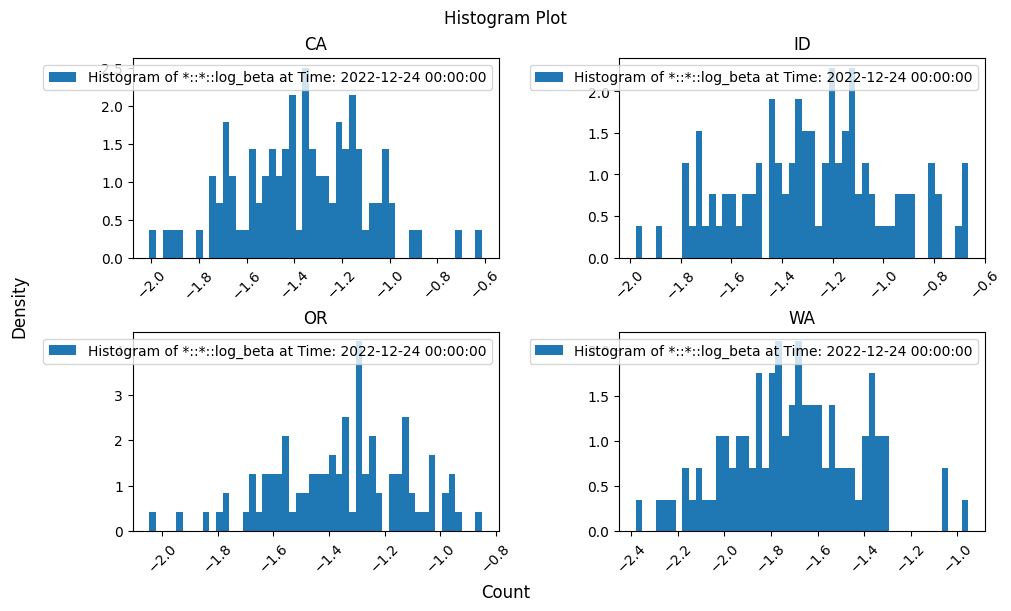

In [10]:
realization = particle_filter_output.select.all()
time = inf_rume.time_frame.select.days(100, 100).group("day").agg()
geo = inf_rume.scope.select.all()
quantity = particle_filter_output.param_select.by_name("*::*::log_beta")

plotter.histogram(
    geo,
    time,
    quantity,
    ncols=2,
    hist_kwargs=[{"color": "tab:blue", "density": True, "bins": 50}],
    title="Histogram Plot",
)